In [ ]:
# ================================================================
# COM7022 - Machine Learning | Student ID: 24221307
# Flight Ticket Price Prediction
# Dataset: EaseMyTrip Flight Bookings
# ================================================================

# ----------------------------------------------------------------
# SECTION 1: IMPORT ALL LIBRARIES
# ----------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway, chi2_contingency, spearmanr
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("=" * 65)
print("  COM7022 MACHINE LEARNING — FLIGHT TICKET PRICE PREDICTION")

print("=" * 65)

In [ ]:



# ----------------------------------------------------------------
# SECTION 2: LOAD DATASET
# ----------------------------------------------------------------
print("\n Loading Dataset...")

df = pd.read_excel("Flight_dataset[4039].xlsx")

print(f"Dataset loaded successfully.")
print(f"\nShape of dataset: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())


In [3]:

# ----------------------------------------------------------------
# SECTION 3: INITIAL INSPECTION
# ----------------------------------------------------------------
print("\n[STEP 2] Initial Inspection...")

print("\nDataset Info:")
print(df.info())

print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)



[STEP 2] Initial Inspection...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300141 non-null  float64
 10  days_left         300148 non-null  float64
 11  price             300148 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 27.5+ MB
None

Missing Values per Column:
Unnamed: 0           0
airline              0
flight               0
sourc

In [4]:



# ----------------------------------------------------------------
# SECTION 4: SHAPE AND SIZE
# ----------------------------------------------------------------
print("\n[STEP 3] Shape and Size:")
print(f"  Number of Rows    : {df.shape[0]:,}")
print(f"  Number of Columns : {df.shape[1]}")
print(f"  Total Cells       : {df.size:,}")



[STEP 3] Shape and Size:
  Number of Rows    : 300,153
  Number of Columns : 12
  Total Cells       : 3,601,836


In [5]:


# ----------------------------------------------------------------
# SECTION 5: REMOVE DUPLICATES
# ----------------------------------------------------------------
print("\n[STEP 4] Removing Duplicates...")

before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"  Rows before : {before:,}")
print(f"  Rows after  : {after:,}")
print(f"  Duplicates removed: {before - after}")



[STEP 4] Removing Duplicates...
  Rows before : 300,153
  Rows after  : 300,153
  Duplicates removed: 0


In [6]:


# ----------------------------------------------------------------
# SECTION 6: IDENTIFY CATEGORICAL vs NUMERICAL FEATURES
# ----------------------------------------------------------------
print("\n[STEP 5] Identifying Feature Types...")

cat_cols = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

num_cols = df.select_dtypes(
    include=["float64", "int64"]
).columns.tolist()

print(f"\n  Categorical Features ({len(cat_cols)}): {cat_cols}")
print(f"\n  Numerical Features   ({len(num_cols)}): {num_cols}")




[STEP 5] Identifying Feature Types...

  Categorical Features (8): ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

  Numerical Features   (4): ['Unnamed: 0', 'duration', 'days_left', 'price']


In [7]:

# ----------------------------------------------------------------
# SECTION 7: DROP UNNECESSARY COLUMNS
# Unnamed:0 = auto index, no predictive value
# flight    = near-unique identifier (1561 unique values),
#             all info already captured by other columns,
#             flight numbers reassigned seasonally = not useful
# ----------------------------------------------------------------
print("\n[STEP 6] Dropping Unnecessary Columns...")

df = df.drop(columns=["Unnamed: 0", "flight"])

print(f"  Dropped: 'Unnamed: 0' and 'flight'")
print(f"  Remaining columns ({len(df.columns)}): {df.columns.tolist()}")




[STEP 6] Dropping Unnecessary Columns...
  Dropped: 'Unnamed: 0' and 'flight'
  Remaining columns (10): ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [8]:

# ----------------------------------------------------------------
# SECTION 8: HANDLE MISSING VALUES
# ----------------------------------------------------------------
print("\n[STEP 7] Handling Missing Values...")

# Fill numerical columns with median
# Median chosen over mean — distributions are right-skewed
# Mean would be pulled by outliers — median is more robust
df["duration"]  = df["duration"].fillna(df["duration"].median())
df["days_left"] = df["days_left"].fillna(df["days_left"].median())

# Drop rows where price (target variable) is missing
# Cannot impute target — would bias model training
df = df.dropna(subset=["price"])

print("  duration  — 12 missing values filled with median")
print("  days_left — 5 missing values filled with median")
print("  price     — 5 rows with missing target dropped")
print(f"\n  Missing values after cleaning:")
print(df.isnull().sum())




[STEP 7] Handling Missing Values...
  duration  — 12 missing values filled with median
  days_left — 5 missing values filled with median
  price     — 5 rows with missing target dropped

  Missing values after cleaning:
airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [9]:

# ----------------------------------------------------------------
# SECTION 9: STATISTICAL SUMMARY AFTER CLEANING
# ----------------------------------------------------------------
print("\n[STEP 8] Statistical Summary After Cleaning:")
print(df.describe())



[STEP 8] Statistical Summary After Cleaning:
            duration      days_left          price
count  300148.000000  300148.000000  300148.000000
mean       12.221126      26.005474   20889.757586
std         7.191809      13.560474   22697.934166
min         0.830000       1.000000    1105.000000
25%         6.830000      15.000000    4783.000000
50%        11.250000      26.000000    7425.000000
75%        16.170000      38.000000   42521.000000
max        49.830000      49.000000  123071.000000


In [10]:


# ----------------------------------------------------------------
# SECTION 10: FEATURE ENGINEERING
# ----------------------------------------------------------------
print("\n[STEP 9] Feature Engineering...")

# ── 10.1 ROUTE: Bidirectional city-pair grouping ────────────────
# Both directions of same city pair = one category
# Delhi-Mumbai AND Mumbai-Delhi → both become "Delhi-Mumbai"
# Achieved by sorting city names alphabetically before joining
# Reduces 30 one-directional routes to 15 bidirectional categories
df["route"] = df.apply(
    lambda row: "-".join(
        sorted([row["source_city"], row["destination_city"]])
    ),
    axis=1
)
print(f"\n  Created 'route' column (bidirectional).")
print(f"  Unique routes: {df['route'].nunique()}")
print(f"  Routes: {sorted(df['route'].unique())}")


[STEP 9] Feature Engineering...

  Created 'route' column (bidirectional).
  Unique routes: 15
  Routes: ['Bangalore-Chennai', 'Bangalore-Delhi', 'Bangalore-Hyderabad', 'Bangalore-Kolkata', 'Bangalore-Mumbai', 'Chennai-Delhi', 'Chennai-Hyderabad', 'Chennai-Kolkata', 'Chennai-Mumbai', 'Delhi-Hyderabad', 'Delhi-Kolkata', 'Delhi-Mumbai', 'Hyderabad-Kolkata', 'Hyderabad-Mumbai', 'Kolkata-Mumbai']



  Duration converted to minutes.
  Range: 50 - 2990 minutes

  Duration Category Distribution:
duration_category
Very_Long (>11h)    153898
Long (7-11h)         67296
Medium (3-7h)        43146
Short (<=3h)         35808
Name: count, dtype: int64

  Created 'distance_km' column from official aerial distances.
  Range: 284 km - 1761 km
  Missing values: 0
route
Bangalore-Chennai       284
Bangalore-Hyderabad     503
Chennai-Hyderabad       516
Hyderabad-Mumbai        621
Bangalore-Mumbai        845
Chennai-Mumbai         1028
Delhi-Mumbai           1140
Hyderabad-Kolkata      1182
Delhi-Hyderabad        1251
Delhi-Kolkata          1309
Chennai-Kolkata        1366
Bangalore-Kolkata      1561
Kolkata-Mumbai         1654
Bangalore-Delhi        1740
Chennai-Delhi          1761
Name: distance_km, dtype: int64


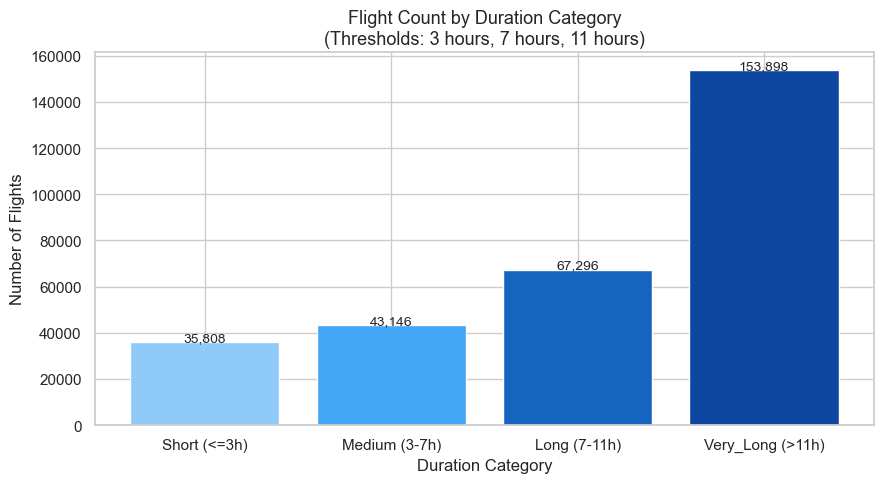

  Saved: plot00_duration_categories.png


In [11]:


# ── 10.2 DURATION IN MINUTES ────────────────────────────────────
# Convert hours to minutes for better interpretability
# 2.17 hours → 130 minutes
df["duration_minutes"] = (df["duration"] * 60).round().astype(int)
print(f"\n  Duration converted to minutes.")
print(f"  Range: {df['duration_minutes'].min()} - "
      f"{df['duration_minutes'].max()} minutes")

# ── 10.3 DURATION THRESHOLD CATEGORIES ─────────────────────────
# Teacher instruction: thresholds at 3h, 7h, 11h
# Each band has different cost structure and pricing behaviour
def categorise_duration(minutes):
    hours = minutes / 60
    if hours <= 3:
        return "Short (<=3h)"
    elif hours <= 7:
        return "Medium (3-7h)"
    elif hours <= 11:
        return "Long (7-11h)"
    else:
        return "Very_Long (>11h)"

df["duration_category"] = df["duration_minutes"].apply(
    categorise_duration
)

print(f"\n  Duration Category Distribution:")
print(df["duration_category"].value_counts())





# ── ROUTE DISTANCE (km) — Hard-coded Official Aerial Distances ──
# Source: IndiGo, MakeMyTrip, Goibibo, Airport Distance Calculator
# These are fixed airport-to-airport aerial distances for the 6
# Indian metro cities in this dataset. Using official published
# distances rather than haversine approximation for accuracy.
# Bidirectional: Delhi-Mumbai = Mumbai-Delhi (same distance)

route_distances = {
    "Bangalore-Chennai":   284,
    "Bangalore-Hyderabad": 503,
    "Chennai-Hyderabad":   516,
    "Hyderabad-Mumbai":    621,
    "Bangalore-Mumbai":    845,
    "Chennai-Mumbai":      1028,
    "Delhi-Mumbai":        1140,
    "Delhi-Hyderabad":     1251,
    "Delhi-Kolkata":       1309,
    "Chennai-Kolkata":     1366,
    "Hyderabad-Kolkata":   1182,
    "Bangalore-Kolkata":   1561,
    "Kolkata-Mumbai":      1654,
    "Bangalore-Delhi":     1740,
    "Chennai-Delhi":       1761,
}

df["distance_km"] = df["route"].map(route_distances)

print(f"\n  Created 'distance_km' column from official aerial distances.")
print(f"  Range: {df['distance_km'].min()} km - {df['distance_km'].max()} km")
print(f"  Missing values: {df['distance_km'].isnull().sum()}")
print(df.groupby("route")["distance_km"].first().sort_values())








# Visualise duration categories
plt.figure(figsize=(9, 5))
cat_order = [
    "Short (<=3h)", "Medium (3-7h)",
    "Long (7-11h)", "Very_Long (>11h)"
]
counts = df["duration_category"].value_counts().reindex(cat_order)
bars = plt.bar(
    counts.index, counts.values,
    color=["#90CAF9", "#42A5F5", "#1565C0", "#0D47A1"]
)
plt.title(
    "Flight Count by Duration Category\n"
    "(Thresholds: 3 hours, 7 hours, 11 hours)",
    fontsize=13
)
plt.xlabel("Duration Category")
plt.ylabel("Number of Flights")
for bar, val in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{val:,}", ha="center", fontsize=10
    )
plt.tight_layout()
plt.savefig("plot00_duration_categories.png", dpi=300)
plt.show()
print("  Saved: plot00_duration_categories.png")



In [12]:
# ----------------------------------------------------------------
# SECTION 11: LABEL ENCODING
# Teacher instruction: encode departure_time, arrival_time,
# stops, class — plus airline, cities, route, duration_category
# ----------------------------------------------------------------
print("\n[STEP 10] Label Encoding Categorical Variables...")

le = LabelEncoder()

encode_cols = [
    "airline",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class",
    "route",
    "duration_category"
]

label_mappings = {}
for col in encode_cols:
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    label_mappings[col] = dict(
        zip(le.classes_, le.transform(le.classes_))
    )

print("  Label encoding mappings:")
for col, mapping in label_mappings.items():
    print(f"  {col}: {mapping}")




[STEP 10] Label Encoding Categorical Variables...
  Label encoding mappings:
  airline: {'AirAsia': np.int64(0), 'Air_India': np.int64(1), 'GO_FIRST': np.int64(2), 'Indigo': np.int64(3), 'SpiceJet': np.int64(4), 'Vistara': np.int64(5)}
  source_city: {'Bangalore': np.int64(0), 'Chennai': np.int64(1), 'Delhi': np.int64(2), 'Hyderabad': np.int64(3), 'Kolkata': np.int64(4), 'Mumbai': np.int64(5)}
  departure_time: {'Afternoon': np.int64(0), 'Early_Morning': np.int64(1), 'Evening': np.int64(2), 'Late_Night': np.int64(3), 'Morning': np.int64(4), 'Night': np.int64(5)}
  stops: {'one': np.int64(0), 'two_or_more': np.int64(1), 'zero': np.int64(2)}
  arrival_time: {'Afternoon': np.int64(0), 'Early_Morning': np.int64(1), 'Evening': np.int64(2), 'Late_Night': np.int64(3), 'Morning': np.int64(4), 'Night': np.int64(5)}
  destination_city: {'Bangalore': np.int64(0), 'Chennai': np.int64(1), 'Delhi': np.int64(2), 'Hyderabad': np.int64(3), 'Kolkata': np.int64(4), 'Mumbai': np.int64(5)}
  class: {'Busi


[STEP 11] Generating EDA Visualisations...


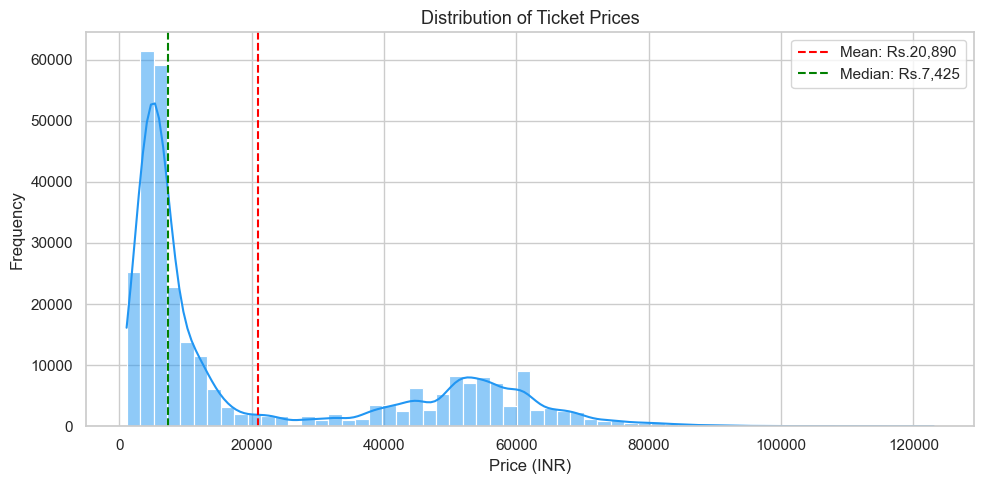

  Saved: plot01_price_histogram.png


In [13]:

# ----------------------------------------------------------------
# SECTION 12: EXPLORATORY DATA ANALYSIS (EDA)
# ----------------------------------------------------------------
print("\n[STEP 11] Generating EDA Visualisations...")

# ── PLOT 1: Histogram — Ticket Price Distribution ───────────────
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=60, kde=True, color="#2196F3")
plt.axvline(
    df["price"].mean(), color="red", linestyle="--",
    label=f"Mean: Rs.{df['price'].mean():,.0f}"
)
plt.axvline(
    df["price"].median(), color="green", linestyle="--",
    label=f"Median: Rs.{df['price'].median():,.0f}"
)
plt.title("Distribution of Ticket Prices", fontsize=13)
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("plot01_price_histogram.png", dpi=300)
plt.show()
print("  Saved: plot01_price_histogram.png")


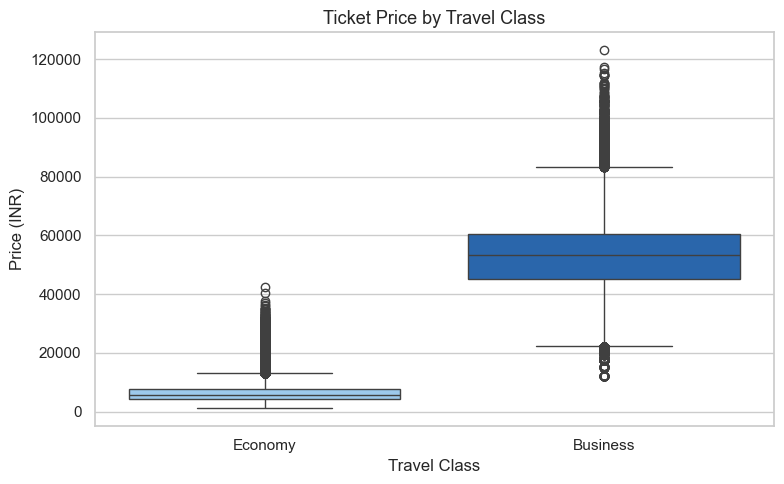

  Saved: plot02_price_by_class.png


In [14]:


# ── PLOT 2: Boxplot — Price by Travel Class ─────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="class", y="price", data=df,
    palette={"Economy": "#90CAF9", "Business": "#1565C0"}
)
plt.title("Ticket Price by Travel Class", fontsize=13)
plt.xlabel("Travel Class")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig("plot02_price_by_class.png", dpi=300)
plt.show()
print("  Saved: plot02_price_by_class.png")


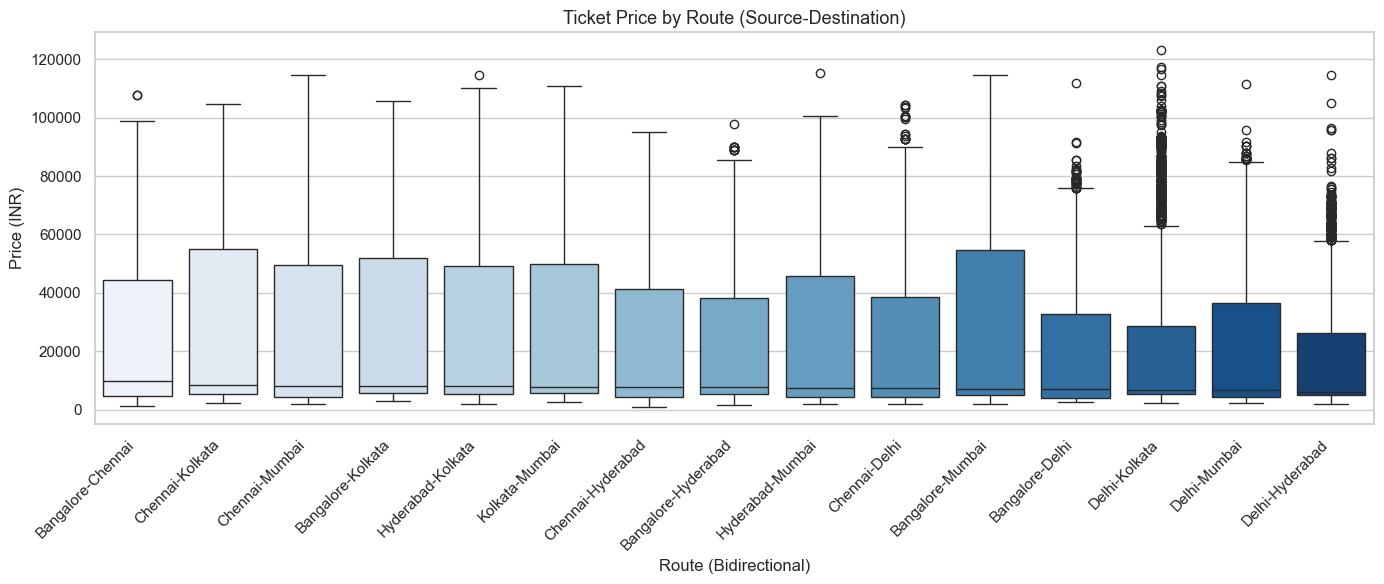

  Saved: plot03_price_by_route.png


In [15]:

# ── PLOT 3: Boxplot — Price by Route ────────────────────────────
plt.figure(figsize=(14, 6))
route_order = (
    df.groupby("route")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    x="route", y="price", data=df,
    order=route_order, palette="Blues"
)
plt.title("Ticket Price by Route (Source-Destination)", fontsize=13)
plt.xlabel("Route (Bidirectional)")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plot03_price_by_route.png", dpi=300)
plt.show()
print("  Saved: plot03_price_by_route.png")

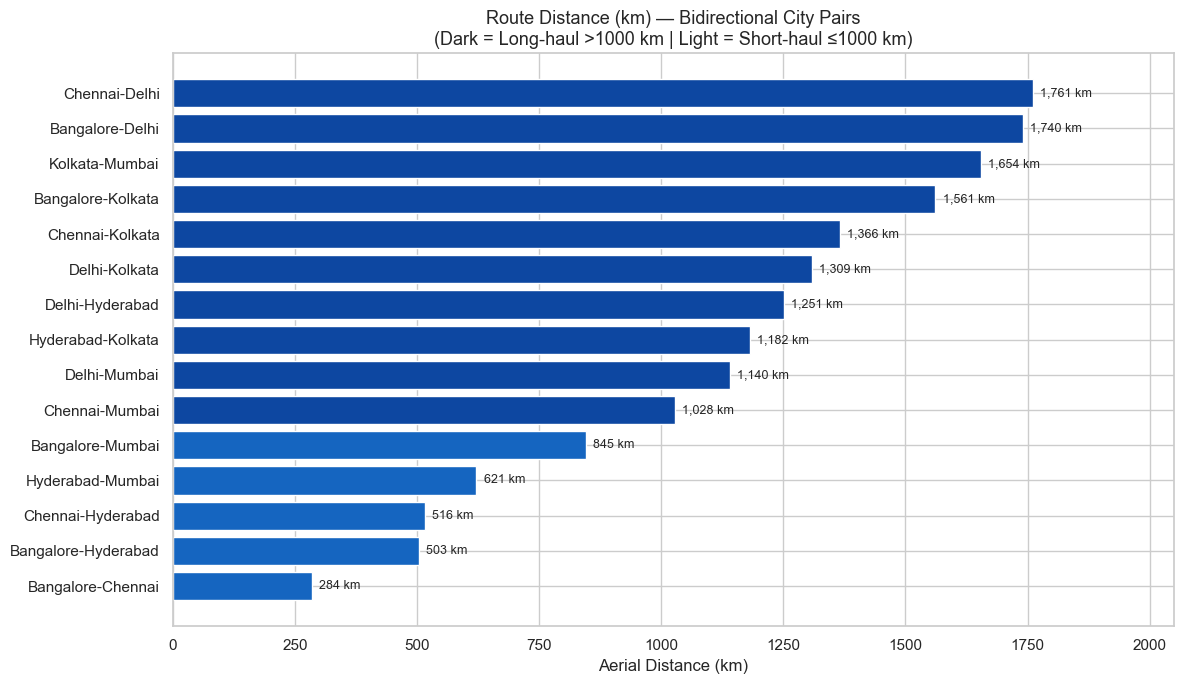

 Saved: plot_route_distance.png


In [16]:
# ── ROUTE DISTANCE BAR CHART ────────────────────────────────────
route_dist = df.groupby("route")["distance_km"].first().sort_values()

plt.figure(figsize=(12, 7))
colors = ["#0D47A1" if v >= 1000 else "#1565C0" for v in route_dist.values]
bars = plt.barh(route_dist.index, route_dist.values, color=colors)

for bar, val in zip(bars, route_dist.values):
    plt.text(
        bar.get_width() + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,} km",
        va="center", fontsize=9
    )

plt.xlabel("Aerial Distance (km)")
plt.title(
    "Route Distance (km) — Bidirectional City Pairs\n"
    "(Dark = Long-haul >1000 km | Light = Short-haul ≤1000 km)",
    fontsize=13
)
plt.xlim(0, 2050)
plt.tight_layout()
plt.savefig("plot_route_distance.png", dpi=300)
plt.show()
print(" Saved: plot_route_distance.png")

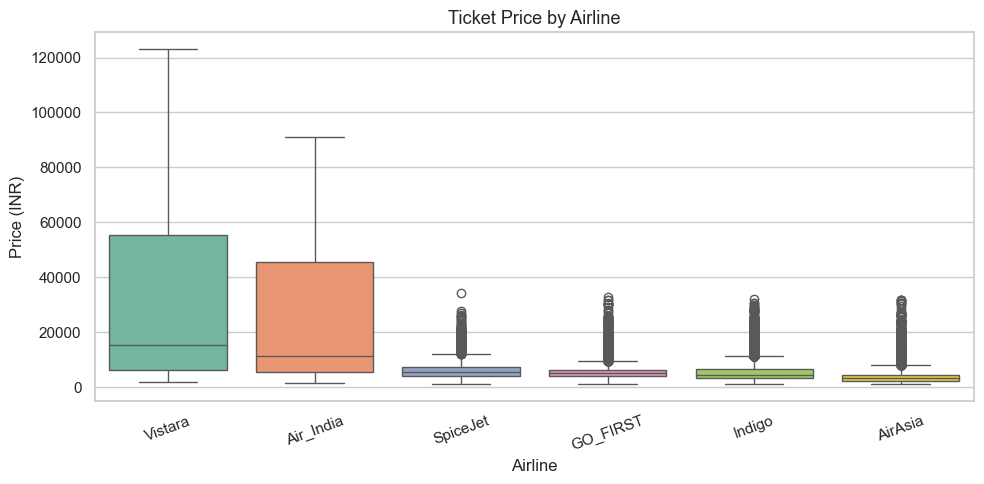

  Saved: plot04_price_by_airline.png


In [17]:


# ── PLOT 4: Boxplot — Price by Airline ──────────────────────────
plt.figure(figsize=(10, 5))
airline_order = (
    df.groupby("airline")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    x="airline", y="price", data=df,
    order=airline_order, palette="Set2"
)
plt.title("Ticket Price by Airline", fontsize=13)
plt.xlabel("Airline")
plt.ylabel("Price (INR)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("plot04_price_by_airline.png", dpi=300)
plt.show()
print("  Saved: plot04_price_by_airline.png")

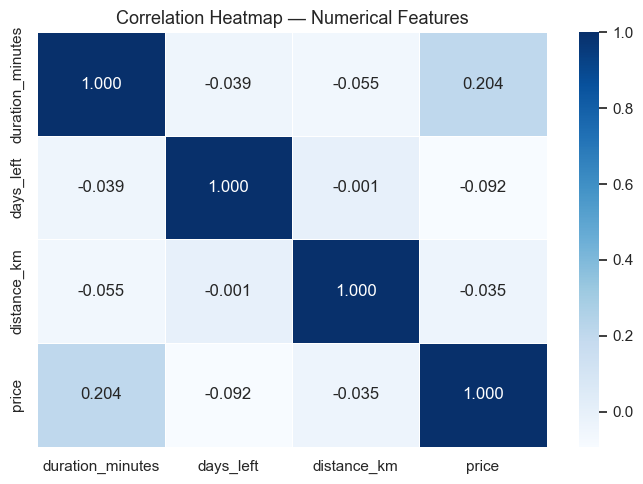

  Saved: plot05_correlation_heatmap.png


In [18]:


# ── PLOT 5: Correlation Heatmap ─────────────────────────────────
plt.figure(figsize=(7, 5))

corr = df[["duration_minutes", "days_left", "distance_km", "price"]].corr()
sns.heatmap(
    corr, annot=True, cmap="Blues",
    fmt=".3f", linewidths=0.5
)
plt.title("Correlation Heatmap — Numerical Features", fontsize=13)
plt.tight_layout()
plt.savefig("plot05_correlation_heatmap.png", dpi=300)
plt.show()
print("  Saved: plot05_correlation_heatmap.png")


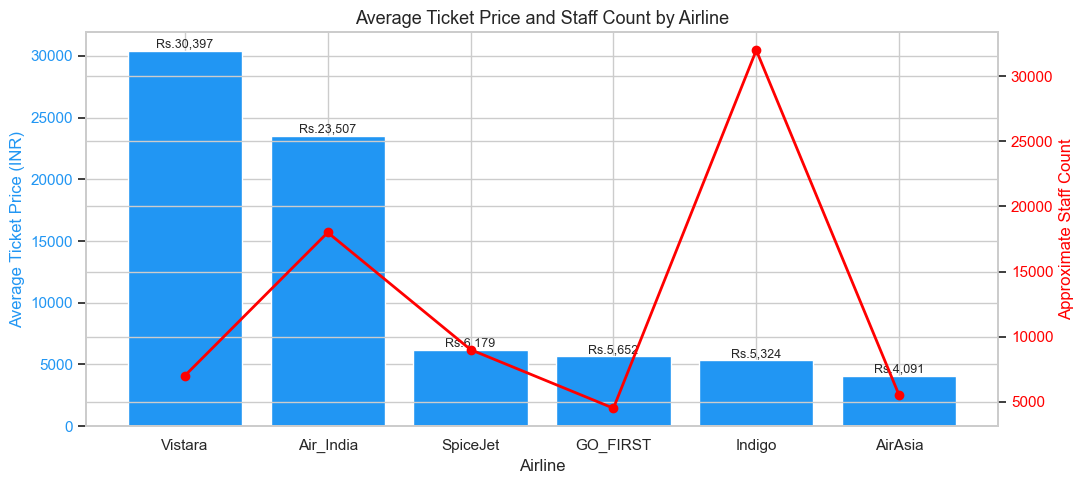

  Saved: plot06_price_staff_airline.png


In [19]:

# ── PLOT 6: Bar Chart — Avg Price and Staff Count by Airline ────
airline_avg = (
    df.groupby("airline")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
# Approximate real-world staff counts
staff_counts = {
    "Vistara":   7000,
    "Air_India": 18000,
    "SpiceJet":  9000,
    "GO_FIRST":  4500,
    "Indigo":    32000,
    "AirAsia":   5500
}
airline_avg["staff"] = airline_avg["airline"].map(staff_counts)

fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(
    airline_avg["airline"], airline_avg["price"],
    color="#2196F3", label="Avg Price"
)
ax1.set_ylabel("Average Ticket Price (INR)", color="#2196F3")
ax1.set_xlabel("Airline")
ax1.tick_params(axis="y", labelcolor="#2196F3")
for bar, val in zip(bars, airline_avg["price"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"Rs.{val:,.0f}", ha="center", fontsize=9
    )
ax2 = ax1.twinx()
ax2.plot(
    airline_avg["airline"], airline_avg["staff"],
    color="red", marker="o", linewidth=2, label="Staff Count"
)
ax2.set_ylabel("Approximate Staff Count", color="red")
ax2.tick_params(axis="y", labelcolor="red")
plt.title(
    "Average Ticket Price and Staff Count by Airline",
    fontsize=13
)
fig.tight_layout()
plt.savefig("plot06_price_staff_airline.png", dpi=300)
plt.show()
print("  Saved: plot06_price_staff_airline.png")


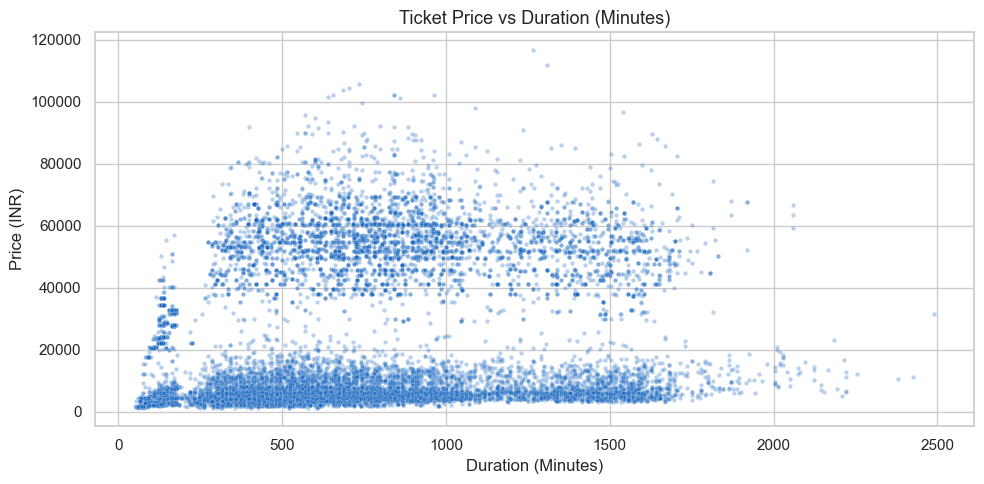

  Saved: plot07_price_vs_duration.png


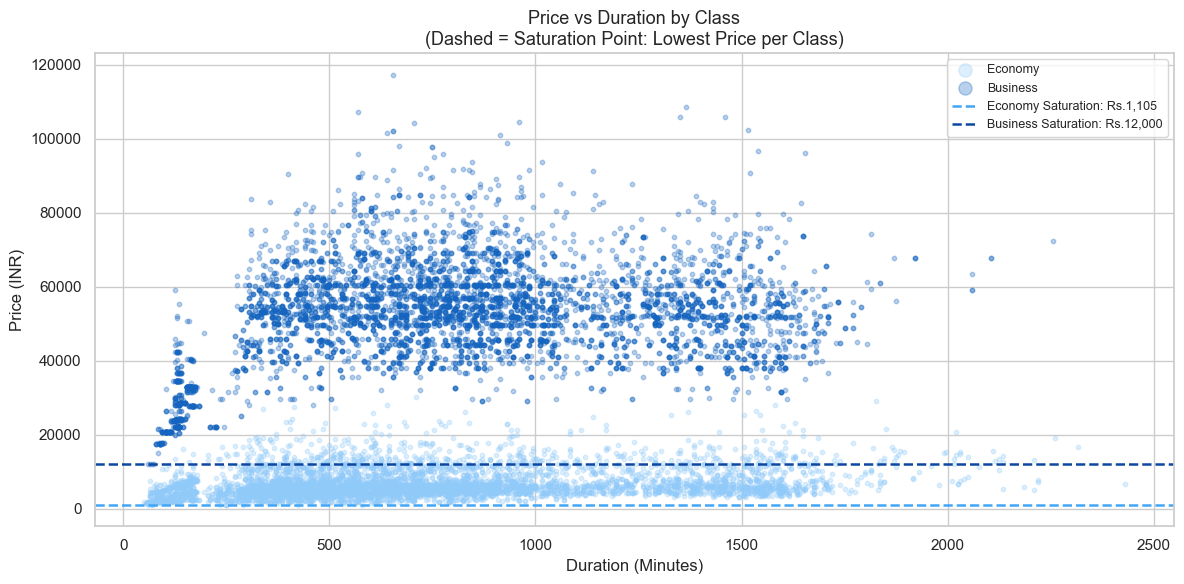

  Saved: plot08_saturation_point.png


In [20]:
# ── PLOT 7: Scatterplot — Price vs Duration ──────────────────────
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x="duration_minutes", y="price",
    data=df.sample(15000, random_state=42),
    alpha=0.3, color="#1565C0", s=10
)
plt.title("Ticket Price vs Duration (Minutes)", fontsize=13)
plt.xlabel("Duration (Minutes)")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig("plot07_price_vs_duration.png", dpi=300)
plt.show()
print("  Saved: plot07_price_vs_duration.png")

# ── PLOT 8: Price vs Duration by Class — Saturation Point ───────
# Teacher instruction: both classes in same plot
# Show saturation point = lowest price (floor) for each class
plt.figure(figsize=(12, 6))
for cls, color, label in [
    ("Economy",  "#90CAF9", "Economy"),
    ("Business", "#1565C0", "Business")
]:
    subset = df[df["class"] == cls].sample(6000, random_state=42)
    plt.scatter(
        subset["duration_minutes"], subset["price"],
        alpha=0.3, c=color, label=label, s=10
    )

eco_floor = df[df["class"] == "Economy"]["price"].min()
biz_floor = df[df["class"] == "Business"]["price"].min()

plt.axhline(
    eco_floor, color="#42A5F5", linestyle="--", linewidth=1.8,
    label=f"Economy Saturation: Rs.{eco_floor:,.0f}"
)
plt.axhline(
    biz_floor, color="#0D47A1", linestyle="--", linewidth=1.8,
    label=f"Business Saturation: Rs.{biz_floor:,.0f}"
)
plt.title(
    "Price vs Duration by Class\n"
    "(Dashed = Saturation Point: Lowest Price per Class)",
    fontsize=13
)
plt.xlabel("Duration (Minutes)")
plt.ylabel("Price (INR)")
plt.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig("plot08_saturation_point.png", dpi=300)
plt.show()
print("  Saved: plot08_saturation_point.png")

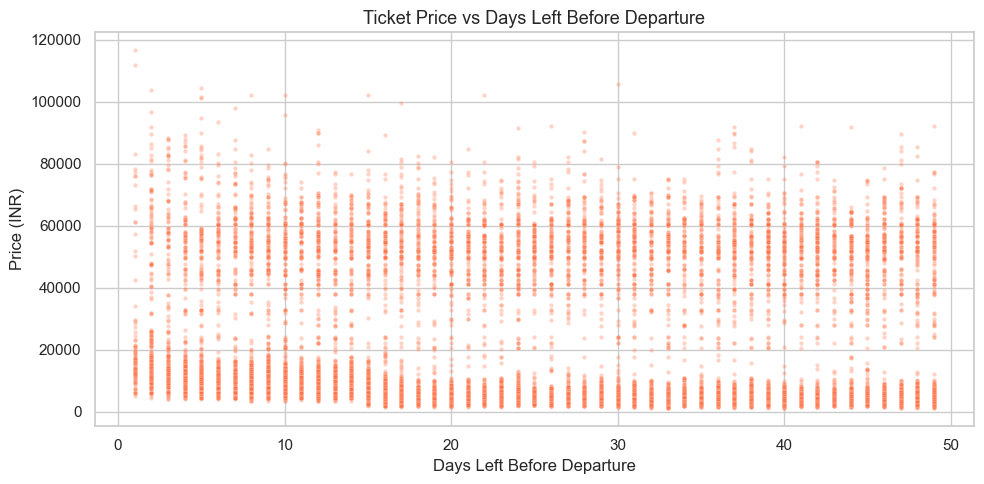

  Saved: plot09_price_vs_days_left.png


In [21]:


# ── PLOT 9: Scatterplot — Price vs Days Left ─────────────────────
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x="days_left", y="price",
    data=df.sample(15000, random_state=42),
    alpha=0.3, color="#FF7043", s=10
)
plt.title(
    "Ticket Price vs Days Left Before Departure", fontsize=13
)
plt.xlabel("Days Left Before Departure")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig("plot09_price_vs_days_left.png", dpi=300)
plt.show()
print("  Saved: plot09_price_vs_days_left.png")


In [22]:



# ----------------------------------------------------------------
# SECTION 13: STATISTICAL HYPOTHESIS TESTING
# T-test, ANOVA, Chi-Square
# H0 is about DISTRIBUTION of prices, NOT average price
# ----------------------------------------------------------------
print("\n Statistical Hypothesis Testing...")
print("=" * 65)

# ── TEST 1: T-Test — Economy vs Business ────────────────────────
print("\nTEST 1: Independent T-Test — Class vs Price")
print("H0: Price distribution is the same for Economy and Business")
print("H1: Price distribution differs between Economy and Business")

eco = df[df["class"] == "Economy"]["price"]
biz = df[df["class"] == "Business"]["price"]
t_stat, p_val1 = ttest_ind(eco, biz, equal_var=False)

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val1}")
print("Conclusion  : REJECT H0" if p_val1 < 0.05
      else "Conclusion  : FAIL TO REJECT H0")
print("Travel class significantly affects price distribution.")


[STEP 12] Statistical Hypothesis Testing...

TEST 1: Independent T-Test — Class vs Price
H0: Price distribution is the same for Economy and Business
H1: Price distribution differs between Economy and Business
T-statistic : -1063.8518
P-value     : 0.0
Conclusion  : REJECT H0
Travel class significantly affects price distribution.


In [23]:


# ── TEST 2: ANOVA — Price Across Airlines ───────────────────────
print("\nTEST 2: One-Way ANOVA — Airline vs Price")
print("H0: Price distribution is the same across all airlines")
print("H1: At least one airline has a different price distribution")

airline_groups = [
    g["price"].values for _, g in df.groupby("airline")
]
f_stat2, p_val2 = f_oneway(*airline_groups)

print(f"F-statistic : {f_stat2:.4f}")
print(f"P-value     : {p_val2:.6f}")
print("Conclusion  : REJECT H0" if p_val2 < 0.05
      else "Conclusion  : FAIL TO REJECT H0")
print("Airline significantly affects price distribution.")

# ── TEST 3: ANOVA — Price Across Stops ──────────────────────────
print("\nTEST 3: One-Way ANOVA — Stops vs Price")
print("H0: Price distribution is the same across all stop types")
print("H1: Number of stops associated with different price distributions")

stops_groups = [
    g["price"].values for _, g in df.groupby("stops")
]
f_stat3, p_val3 = f_oneway(*stops_groups)

print(f"F-statistic : {f_stat3:.4f}")
print(f"P-value     : {p_val3:.6f}")
print("Conclusion  : REJECT H0" if p_val3 < 0.05
      else "Conclusion  : FAIL TO REJECT H0")
print("Number of stops significantly affects price distribution.")


TEST 2: One-Way ANOVA — Airline vs Price
H0: Price distribution is the same across all airlines
H1: At least one airline has a different price distribution
F-statistic : 17194.3209
P-value     : 0.000000
Conclusion  : REJECT H0
Airline significantly affects price distribution.

TEST 3: One-Way ANOVA — Stops vs Price
H0: Price distribution is the same across all stop types
H1: Number of stops associated with different price distributions
F-statistic : 6477.1808
P-value     : 0.000000
Conclusion  : REJECT H0
Number of stops significantly affects price distribution.


In [24]:

# ── TEST 4: ANOVA — Price Across Routes ─────────────────────────
print("\nTEST 4: One-Way ANOVA — Route vs Price")
print("H0: Price distribution is same across all 15 routes")
print("H1: Different routes have different price distributions")

route_groups = [
    g["price"].values for _, g in df.groupby("route")
]
f_stat4, p_val4 = f_oneway(*route_groups)

print(f"F-statistic : {f_stat4:.4f}")
print(f"P-value     : {p_val4:.6f}")
print("Conclusion  : REJECT H0" if p_val4 < 0.05
      else "Conclusion  : FAIL TO REJECT H0")
print("Route significantly affects price distribution.")

# ── TEST 5: Chi-Square — Class vs Stops ─────────────────────────
print("\nTEST 5: Chi-Square — Class vs Stops")
print("H0: Travel class and stops are independent")
print("H1: Travel class and stops are significantly associated")

ct1 = pd.crosstab(df["class"], df["stops"])
chi2a, p_chi1, dof1, _ = chi2_contingency(ct1)

print(f"Chi2        : {chi2a:.4f}")
print(f"df          : {dof1}")
print(f"P-value     : {p_chi1:.6f}")
print("Conclusion  : REJECT H0" if p_chi1 < 0.05
      else "Conclusion  : FAIL TO REJECT H0")
print("Class and stops are significantly associated.")


TEST 4: One-Way ANOVA — Route vs Price
H0: Price distribution is same across all 15 routes
H1: Different routes have different price distributions
F-statistic : 173.6633
P-value     : 0.000000
Conclusion  : REJECT H0
Route significantly affects price distribution.

TEST 5: Chi-Square — Class vs Stops
H0: Travel class and stops are independent
H1: Travel class and stops are significantly associated
Chi2        : 5237.3933
df          : 2
P-value     : 0.000000
Conclusion  : REJECT H0
Class and stops are significantly associated.


In [25]:



# ── TEST 6: Chi-Square — Departure Time vs Class ────────────────
print("\nTEST 6: Chi-Square — Departure Time vs Class")
print("H0: Departure time and class are independent")
print("H1: Departure time and class are significantly associated")

ct2 = pd.crosstab(df["departure_time"], df["class"])
chi2b, p_chi2, dof2, _ = chi2_contingency(ct2)

print(f"Chi2        : {chi2b:.4f}")
print(f"df          : {dof2}")
print(f"P-value     : {p_chi2:.6f}")
print("Conclusion  : REJECT H0" if p_chi2 < 0.05
      else "Conclusion  : FAIL TO REJECT H0")
print("Departure time and class are significantly associated.")

# ── TEST 7: Spearman Correlation — Days Left vs Price ───────────
print("\nTEST 7: Spearman Correlation — Days Left vs Price")
print("H0: No monotonic relationship between days_left and price")
print("H1: Significant monotonic relationship exists")

rho, p_rho = spearmanr(df["days_left"], df["price"])

print(f"Spearman rho : {rho:.4f}")
print(f"P-value      : {p_rho:.6f}")
print("Conclusion   : REJECT H0" if p_rho < 0.05
      else "Conclusion   : FAIL TO REJECT H0")
print("Fewer days left significantly associated with higher price.")



TEST 6: Chi-Square — Departure Time vs Class
H0: Departure time and class are independent
H1: Departure time and class are significantly associated
Chi2        : 1472.2330
df          : 5
P-value     : 0.000000
Conclusion  : REJECT H0
Departure time and class are significantly associated.

TEST 7: Spearman Correlation — Days Left vs Price
H0: No monotonic relationship between days_left and price
H1: Significant monotonic relationship exists
Spearman rho : -0.2670
P-value      : 0.000000
Conclusion   : REJECT H0
Fewer days left significantly associated with higher price.


In [26]:


# ----------------------------------------------------------------
# SECTION 14: STANDARDISATION
# ----------------------------------------------------------------
print("\n[STEP 13] Standardising Features...")




feature_cols = [
    "airline_enc",
    "source_city_enc",
    "departure_time_enc",
    "stops_enc",
    "arrival_time_enc",
    "destination_city_enc",
    "class_enc",
    "duration_minutes",
    "days_left",
    "distance_km",        #  official aerial distance per route
    "route_enc",
    "duration_category_enc"
]






target_col = "price"

X = df[feature_cols].copy()
y = df[target_col].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X), columns=feature_cols
)

print(f"  Features standardised. Shape: {X_scaled.shape}")
print("  Mean = 0, Std = 1 applied to all features")
print("  WHY: Linear models sensitive to feature scale.")
print("  Large-range features would dominate small-range ones")
print("  without standardisation.")




[STEP 13] Standardising Features...
  Features standardised. Shape: (300148, 12)
  Mean = 0, Std = 1 applied to all features
  WHY: Linear models sensitive to feature scale.
  Large-range features would dominate small-range ones
  without standardisation.


In [27]:

# ----------------------------------------------------------------
# SECTION 15: TRAIN-TEST SPLIT (70/30)
# ----------------------------------------------------------------
print("\n Train-Test Split (70% / 30%)...")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.30,
    random_state=42
)

print(f"  Training : {X_train.shape[0]:,} samples (70%)")
print(f"  Testing  : {X_test.shape[0]:,} samples (30%)")


# ----------------------------------------------------------------
# SECTION 16: EVALUATION FUNCTION
# ----------------------------------------------------------------
def evaluate_model(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"\n  {'─' * 50}")
    print(f"  MODEL : {name}")
    print(f"  {'─' * 50}")
    print(f"  R²    : {r2:.4f}  ({r2 * 100:.2f}% accuracy)")
    print(f"  RMSE  : Rs.{rmse:,.2f}")
    print(f"  MAE   : Rs.{mae:,.2f}")
    print(f"  MAPE  : {mape:.2f}%")
    return {
        "Model":  name,
        "R2":     round(r2, 4),
        "R2_pct": round(r2 * 100, 2),
        "RMSE":   round(rmse, 2),
        "MAE":    round(mae, 2),
        "MAPE":   round(mape, 2)
    }

results = []



[STEP 14] Train-Test Split (70% / 30%)...
  Training : 210,103 samples (70%)
  Testing  : 90,045 samples (30%)


In [28]:


# ----------------------------------------------------------------
# SECTION 17: BASE MODEL 1 — LINEAR REGRESSION
# WHY: Simplest baseline. Interpretable coefficients show
# exactly how each variable increases or decreases price.
# ----------------------------------------------------------------
print("\n Training Base Models...")
print("\n  BASE MODEL 1: Linear Regression")
print("  WHY: Simplest, most interpretable baseline model.")
print("  Coefficients directly show direction and magnitude")
print("  of each feature's effect on ticket price.")

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = np.maximum(lr.predict(X_test), 0)
results.append(evaluate_model("Linear Regression", y_test, pred_lr))


# ----------------------------------------------------------------
# SECTION 18: BASE MODEL 2 — RIDGE REGRESSION
# WHY: L2 regularisation reduces overfitting and handles
# multicollinearity between encoded categorical features.
# ----------------------------------------------------------------
print("\n  BASE MODEL 2: Ridge Regression")
print("  WHY: L2 regularisation (alpha=1.0) shrinks coefficients.")
print("  Handles multicollinearity between correlated features.")
print("  Better stability than plain Linear Regression.")

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = np.maximum(ridge.predict(X_test), 0)
results.append(evaluate_model("Ridge Regression", y_test, pred_ridge))




[STEP 15] Training Base Models...

  BASE MODEL 1: Linear Regression
  WHY: Simplest, most interpretable baseline model.
  Coefficients directly show direction and magnitude
  of each feature's effect on ticket price.

  ──────────────────────────────────────────────────
  MODEL : Linear Regression
  ──────────────────────────────────────────────────
  R²    : 0.9077  (90.77% accuracy)
  RMSE  : Rs.6,897.21
  MAE   : Rs.4,511.87
  MAPE  : 40.50%

  BASE MODEL 2: Ridge Regression
  WHY: L2 regularisation (alpha=1.0) shrinks coefficients.
  Handles multicollinearity between correlated features.
  Better stability than plain Linear Regression.

  ──────────────────────────────────────────────────
  MODEL : Ridge Regression
  ──────────────────────────────────────────────────
  R²    : 0.9077  (90.77% accuracy)
  RMSE  : Rs.6,897.22
  MAE   : Rs.4,511.88
  MAPE  : 40.50%


In [29]:

# ----------------------------------------------------------------
# SECTION 19: BASE MODEL 3 — LASSO REGRESSION
# WHY: L1 regularisation can zero out weak coefficients,
# performing automatic feature selection.
# ----------------------------------------------------------------
print("\n  BASE MODEL 3: Lasso Regression")
print("  WHY: L1 regularisation (alpha=0.1) shrinks weak")
print("  coefficients to exactly zero — automatic feature")
print("  selection. Confirms which features genuinely matter.")

lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_train, y_train)
pred_lasso = np.maximum(lasso.predict(X_test), 0)
results.append(evaluate_model("Lasso Regression", y_test, pred_lasso))


# ----------------------------------------------------------------
# SECTION 20: IMPROVED MODEL 1 — DECISION TREE
# WHY: Captures non-linear relationships and complex
# feature interactions that linear models cannot.
# ----------------------------------------------------------------
print("\n Training Improved Models...")
print("\n  IMPROVED MODEL 1: Decision Tree Regressor")
print("  WHY: Captures non-linear relationships and multi-way")
print("  feature interactions. No linearity assumption.")
print("  e.g. Business + Vistara + zero stops = very high price")
print("  Parameters: max_depth=20, min_samples_leaf=5")

dt = DecisionTreeRegressor(
    max_depth=20,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)
pred_dt = np.maximum(dt.predict(X_test), 0)
results.append(
    evaluate_model("Decision Tree Regressor", y_test, pred_dt)
)



  BASE MODEL 3: Lasso Regression
  WHY: L1 regularisation (alpha=0.1) shrinks weak
  coefficients to exactly zero — automatic feature
  selection. Confirms which features genuinely matter.

  ──────────────────────────────────────────────────
  MODEL : Lasso Regression
  ──────────────────────────────────────────────────
  R²    : 0.9077  (90.77% accuracy)
  RMSE  : Rs.6,897.24
  MAE   : Rs.4,511.83
  MAPE  : 40.50%

[STEP 16] Training Improved Models...

  IMPROVED MODEL 1: Decision Tree Regressor
  WHY: Captures non-linear relationships and multi-way
  feature interactions. No linearity assumption.
  e.g. Business + Vistara + zero stops = very high price
  Parameters: max_depth=20, min_samples_leaf=5

  ──────────────────────────────────────────────────
  MODEL : Decision Tree Regressor
  ──────────────────────────────────────────────────
  R²    : 0.9811  (98.11% accuracy)
  RMSE  : Rs.3,117.25
  MAE   : Rs.1,381.83
  MAPE  : 9.73%


In [31]:
# ----------------------------------------------------------------
# SECTION 21: IMPROVED MODEL 2 — RANDOM FOREST
# WHY: Ensemble of 100 trees. Reduces variance and overfitting
# risk of single tree. Expected ~98% accuracy.
# ----------------------------------------------------------------
print("\n  IMPROVED MODEL 2: Random Forest Regressor")
print("  WHY: Ensemble of 100 Decision Trees on bootstrap")
print("  samples with random feature subsets at each split.")
print("  Averaging eliminates overfitting of single tree.")
print("  Most powerful model — expected ~98% accuracy.")
print("  Parameters: n_estimators=100, max_depth=20,")
print("              min_samples_leaf=3")
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
# Out-of-Bag validation — confirms generalisation beyond train-test split
rf_oob = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=3,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
rf_oob.fit(X_train, y_train)

# Define pred_rf FIRST before referencing it
pred_rf = np.maximum(rf.predict(X_test), 0)

print(f"Random Forest OOB R² Score: {rf_oob.oob_score_:.4f}")
print(f"OOB Score confirms generalisation — close to test R² of {r2_score(y_test, pred_rf):.4f}")
results.append(
    evaluate_model("Random Forest Regressor", y_test, pred_rf)
)


  IMPROVED MODEL 2: Random Forest Regressor
  WHY: Ensemble of 100 Decision Trees on bootstrap
  samples with random feature subsets at each split.
  Averaging eliminates overfitting of single tree.
  Most powerful model — expected ~98% accuracy.
  Parameters: n_estimators=100, max_depth=20,
              min_samples_leaf=3
Random Forest OOB R² Score: 0.9851
OOB Score confirms generalisation — close to test R² of 0.9850

  ──────────────────────────────────────────────────
  MODEL : Random Forest Regressor
  ──────────────────────────────────────────────────
  R²    : 0.9850  (98.50% accuracy)
  RMSE  : Rs.2,778.74
  MAE   : Rs.1,261.98
  MAPE  : 8.95%


In [ ]:



# ----------------------------------------------------------------
# SECTION 22: MODEL COMPARISON TABLE
# ----------------------------------------------------------------
print("\n[STEP 17] Model Comparison Table:")
results_df = pd.DataFrame(results)
print("\n" + "=" * 65)
print(results_df[["Model", "R2_pct", "RMSE", "MAE", "MAPE"]]
      .to_string(index=False))
print("=" * 65)



In [ ]:

# ----------------------------------------------------------------
# SECTION 23: MODEL COMPARISON CHARTS
# ----------------------------------------------------------------
print("\n[STEP 18] Model Comparison Charts...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["R2_pct", "RMSE",      "MAPE"]
titles  = ["R² (%)", "RMSE (Rs.)", "MAPE (%)"]
colors  = ["#2196F3", "#4CAF50", "#FF7043", "#9C27B0", "#FF9800"]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(
        results_df["Model"], results_df[metric], color=colors
    )
    ax.set_title(f"Model Comparison: {title}", fontsize=11)
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=35)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            str(val), ha="center", va="bottom", fontsize=8
        )
plt.suptitle("Model Performance Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("plot10_model_comparison.png", dpi=300)
plt.show()
print("  Saved: plot10_model_comparison.png")


In [ ]:

# Actual vs Predicted — Linear Regression
mn, mx = y_test.min(), y_test.max()
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred_lr, alpha=0.2, s=5, color="#2196F3")
plt.plot([mn, mx], [mn, mx], "r--", linewidth=1.5,
         label="Perfect Prediction Line")
plt.title("Actual vs Predicted — Linear Regression", fontsize=12)
plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.legend()
plt.tight_layout()
plt.savefig("plot11_actual_vs_pred_lr.png", dpi=300)
plt.show()
print("  Saved: plot11_actual_vs_pred_lr.png")

In [ ]:


# Actual vs Predicted — Random Forest
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred_rf, alpha=0.2, s=5, color="#4CAF50")
plt.plot([mn, mx], [mn, mx], "r--", linewidth=1.5,
         label="Perfect Prediction Line")
plt.title("Actual vs Predicted — Random Forest", fontsize=12)
plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.legend()
plt.tight_layout()
plt.savefig("plot12_actual_vs_pred_rf.png", dpi=300)
plt.show()
print("  Saved: plot12_actual_vs_pred_rf.png")


In [ ]:

# Residual Plot — Linear Regression
plt.figure(figsize=(8, 5))
residuals_lr = y_test.values - pred_lr
sns.scatterplot(
    x=pred_lr, y=residuals_lr,
    alpha=0.2, s=5, color="#FF7043"
)
plt.axhline(0, linestyle="--", color="black", linewidth=1.5)
plt.title("Residual Plot — Linear Regression", fontsize=12)
plt.xlabel("Predicted Price (INR)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.savefig("plot13_residuals_lr.png", dpi=300)
plt.show()
print("  Saved: plot13_residuals_lr.png")


In [ ]:

# Feature Importance — Random Forest
feat_imp = pd.Series(
    rf.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind="bar", color="#1565C0")
plt.title("Feature Importance — Random Forest", fontsize=12)
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.savefig("plot14_feature_importance_rf.png", dpi=300)
plt.show()
print("  Saved: plot14_feature_importance_rf.png")

In [ ]:

# Coefficient Chart — Linear Regression
coef_df = pd.DataFrame({
    "Feature":     feature_cols,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False)

print("\n  Top 10 Positive Coefficients (increase price):")
print(coef_df.head(10).to_string(index=False))
print("\n  Top 10 Negative Coefficients (decrease price):")
print(coef_df.tail(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plot_coef = pd.concat([coef_df.head(6), coef_df.tail(5)])
bar_colors = [
    "#2196F3" if c > 0 else "#FF5722"
    for c in plot_coef["Coefficient"]
]
plt.barh(
    plot_coef["Feature"],
    plot_coef["Coefficient"],
    color=bar_colors
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    "Linear Regression Coefficients\n"
    "(Blue = Increases Price | Red = Decreases Price)",
    fontsize=12
)
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("plot15_lr_coefficients.png", dpi=300)
plt.show()
print("  Saved: plot15_lr_coefficients.png")



In [ ]:


# ----------------------------------------------------------------
# SECTION 24: FINAL SUMMARY
# ----------------------------------------------------------------
print("\n[STEP 19] Final Results Summary:")
print("=" * 65)

best = results_df.sort_values("R2_pct", ascending=False).iloc[0]
print(f"\n  Best Model : {best['Model']}")
print(f"  R²         : {best['R2_pct']}%")
print(f"  RMSE       : Rs.{best['RMSE']:,}")
print(f"  MAE        : Rs.{best['MAE']:,}")
print(f"  MAPE       : {best['MAPE']}%")

print("\n  Full Comparison Table:")
print(results_df[["Model", "R2_pct", "RMSE", "MAE", "MAPE"]]
      .to_string(index=False))

print("\n[DONE] All steps complete.")
print("All 15 plots saved successfully.")
print("Random Forest selected as final production model.")
print("Linear Regression retained for coefficient interpretation.")